# DuckDB Image Similarity Search

This notebook uses the reusable embedding layer in `embedding_eval/` and searches
a DuckDB table of image vectors with pure SQL cosine similarity.

Before running the retrieval cells, populate the database:

```bash
uv run python scripts/embed_image_dataset.py --overwrite
```

In [90]:
import sys
import base64
import io
from pathlib import Path

import duckdb
from IPython.display import HTML, display
from PIL import Image

sys.path.append("..")

from embedding_eval.datasets import load_dataset_records
from embedding_eval.duckdb_utils import detect_similarity_expression
from embedding_eval.models import build_model, list_model_configs

PROJECT_ROOT = Path("..").resolve()
DATASETS_DIR = PROJECT_ROOT / "datasets"
DB_PATH = PROJECT_ROOT / "data" / "image_embeddings.duckdb"

available_models = [config.name for config in list_model_configs()]
available_models

['siglip2', 'clip']

In [91]:
def image_to_html(image_path: Path, max_size: int = 180) -> str:
    image = Image.open(image_path)
    thumbnail = image.copy()
    thumbnail.thumbnail((max_size, max_size))
    buffer = io.BytesIO()
    thumbnail.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    image.close()
    thumbnail.close()
    return (
        f'<img src="data:image/png;base64,{encoded}" '
        f'style="max-width:{max_size}px; max-height:{max_size}px; border-radius:8px;" />'
    )

In [92]:
def shorten_text(text: str, max_chars: int = 36) -> str:
    text = " ".join(text.split())
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3].rstrip() + "..."

In [93]:
def build_result_card_html(
    image_path: Path,
    title: str,
    subtitle: str,
    body: str,
    *,
    max_size: int = 180,
) -> str:
    return f"""
    <div style="width: 220px; padding: 10px; border: 1px solid #ddd; border-radius: 10px;">
      <div style="height: {max_size + 10}px; display:flex; align-items:center; justify-content:center;">
        {image_to_html(image_path, max_size=max_size)}
      </div>
      <div style="font-weight: 600; margin-top: 8px;">{title}</div>
      <div style="color: #666; font-size: 12px; margin-top: 4px;">{subtitle}</div>
      <div style="font-size: 12px; margin-top: 8px; line-height: 1.35;">{body}</div>
    </div>
    """


def display_result_matrix(result_columns: list[dict[str, object]]) -> None:
    column_html = []
    for column in result_columns:
        cards = "".join(column["cards"])
        column_html.append(
            f"""
            <div style="flex:1; min-width:0;">
              <h3 style="margin: 0 0 12px 0;">{column["title"]}</h3>
              <div style="display:flex; flex-wrap:wrap; gap:12px;">
                {cards}
              </div>
            </div>
            """
        )

    display(
        HTML(
            f"""
            <div style="display:flex; gap:24px; align-items:flex-start; overflow-x:auto;">
              {"".join(column_html)}
            </div>
            """
        )
    )

## Choose A Dataset

In [94]:
con = duckdb.connect(str(DB_PATH))
embedded_datasets = [
    row[0]
    for row in con.execute(
        "SELECT DISTINCT dataset_name FROM image_embeddings ORDER BY dataset_name"
    ).fetchall()
]
embedded_datasets

['pixabay_clothes']

In [95]:
selected_dataset = (
    "pixabay_clothes"
    if "pixabay_clothes" in embedded_datasets
    else ("demo_image_search" if "demo_image_search" in embedded_datasets else None)
)

if selected_dataset is None:
    raise RuntimeError(
        "No embedded datasets found in DuckDB. Run scripts/embed_image_dataset.py first."
    )

DATASET_ROOT = DATASETS_DIR / selected_dataset
records = load_dataset_records(DATASET_ROOT / "metadata.csv")

print(f"Selected dataset: {selected_dataset}")
[(record.image_id, record.label, record.image_filename) for record in records[:10]]

Selected dataset: pixabay_clothes


[('pixabay-4367577', 't-shirt', 't-shirt-flat-lay-4367577.jpg'),
 ('pixabay-5394561', 'jeans', 'jeans-folded-5394561.jpg'),
 ('pixabay-1839935', 'jeans', 'jeans-folded-1839935.jpg'),
 ('pixabay-2770091', 'sneakers', 'sneakers-centered-2770091.jpg'),
 ('pixabay-2768263', 'sneakers', 'sneakers-centered-2768263.png'),
 ('pixabay-3069891', 'sneakers', 'sneakers-centered-3069891.png'),
 ('pixabay-2770092', 'sneakers', 'sneakers-centered-2770092.png'),
 ('pixabay-5408643', 'sneakers', 'sneakers-centered-5408643.jpg')]

## Choose Queries And Retrieval Modes

In [96]:
query_image_ids = [
    "red-square-1",
    "red-square-2",
] if selected_dataset == "demo_image_search" else [
    records[0].image_id,
    records[min(1, len(records) - 1)].image_id,
    records[min(2, len(records) - 1)].image_id,
]
top_k = 4
retrieval_configs = [
    {"title": "SigLIP2", "model_name": "siglip2", "same_label_only": False},
    {"title": "SigLIP2 + Label", "model_name": "siglip2", "same_label_only": True},
    {"title": "CLIP", "model_name": "clip", "same_label_only": False},
    {"title": "CLIP + Label", "model_name": "clip", "same_label_only": True},
]

print(f"Query image IDs: {query_image_ids}")
retrieval_configs

Query image IDs: ['pixabay-4367577', 'pixabay-5394561', 'pixabay-1839935']


[{'title': 'SigLIP2', 'model_name': 'siglip2', 'same_label_only': False},
 {'title': 'SigLIP2 + Label',
  'model_name': 'siglip2',
  'same_label_only': True},
 {'title': 'CLIP', 'model_name': 'clip', 'same_label_only': False},
 {'title': 'CLIP + Label', 'model_name': 'clip', 'same_label_only': True}]

## Compute The Query Embeddings

In [97]:
models = {
    config["model_name"]: build_model(config["model_name"], batch_size=4)
    for config in retrieval_configs
}

query_entries = []
for query_image_id in query_image_ids:
    query_record = next(record for record in records if record.image_id == query_image_id)
    query_image_path = DATASET_ROOT / "images" / query_record.image_filename
    embeddings = {
        model_name: model.embed_image(query_image_path).tolist()
        for model_name, model in models.items()
    }
    query_entries.append(
        {
            "image_id": query_record.image_id,
            "image_filename": query_record.image_filename,
            "label": query_record.label,
            "caption": query_record.caption,
            "image_path": query_image_path,
            "embeddings": embeddings,
        }
    )

[(entry["image_id"], sorted(entry["embeddings"])) for entry in query_entries]

[('pixabay-4367577', ['clip', 'siglip2']),
 ('pixabay-5394561', ['clip', 'siglip2']),
 ('pixabay-1839935', ['clip', 'siglip2'])]

## Run DuckDB Vector Search

In [98]:
similarity_expression = detect_similarity_expression(con)

base_query_sql = f"""
SELECT
    image_id,
    image_filename,
    label,
    caption,
    {similarity_expression} AS similarity
FROM image_embeddings
WHERE dataset_name = ?
  AND model_name = ?
  AND image_id != ?
"""

result_rows = []
for entry in query_entries:
    for config in retrieval_configs:
        query_sql = base_query_sql
        params = [
            entry["embeddings"][config["model_name"]],
            DATASET_ROOT.name,
            config["model_name"],
            entry["image_id"],
        ]

        if config["same_label_only"]:
            query_sql += "\n  AND label = ?"
            params.append(entry["label"])

        query_sql += "\nORDER BY similarity DESC\nLIMIT ?"
        params.append(top_k)

        results = con.execute(query_sql, params).fetchall()
        result_rows.append(
            {
                "query": entry,
                "config": config,
                "results": results,
            }
        )

[
    (
        row["query"]["image_id"],
        row["config"]["title"],
        [result[0] for result in row["results"]],
    )
    for row in result_rows
]

[('pixabay-4367577',
  'SigLIP2',
  ['pixabay-2597210',
   'pixabay-1839935',
   'pixabay-1839935',
   'pixabay-2770091']),
 ('pixabay-4367577', 'SigLIP2 + Label', ['pixabay-8012239']),
 ('pixabay-4367577',
  'CLIP',
  ['pixabay-2597210',
   'pixabay-2160265',
   'pixabay-1839935',
   'pixabay-1839935']),
 ('pixabay-4367577', 'CLIP + Label', ['pixabay-8012239']),
 ('pixabay-5394561',
  'SigLIP2',
  ['pixabay-1686630', 'pixabay-1686633', 'pixabay-200042', 'pixabay-2160265']),
 ('pixabay-5394561',
  'SigLIP2 + Label',
  ['pixabay-1686630', 'pixabay-1686633', 'pixabay-200042', 'pixabay-2160265']),
 ('pixabay-5394561',
  'CLIP',
  ['pixabay-4178233', 'pixabay-4367577', 'pixabay-4367577', 'pixabay-279563']),
 ('pixabay-5394561',
  'CLIP + Label',
  ['pixabay-4178233',
   'pixabay-2160265',
   'pixabay-2597210',
   'pixabay-1686630']),
 ('pixabay-1839935',
  'SigLIP2',
  ['pixabay-2597210',
   'pixabay-4367577',
   'pixabay-4367577',
   'pixabay-2160265']),
 ('pixabay-1839935',
  'SigLIP2 + 

## Compare Retrieval Modes For Each Query


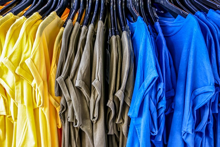
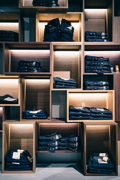
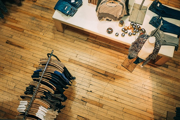
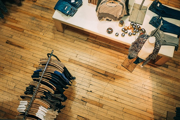
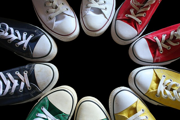
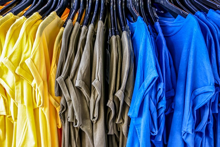
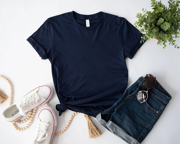
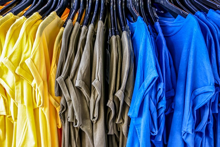
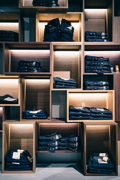
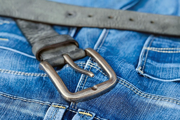
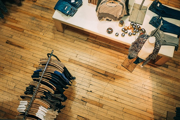
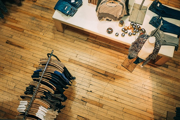
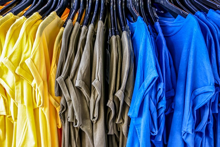
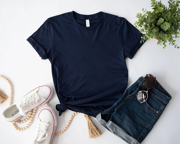


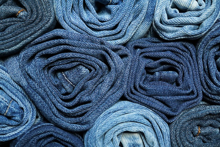
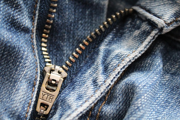
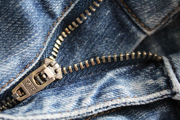
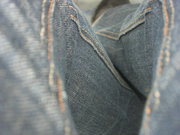
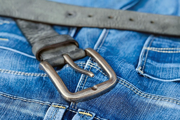
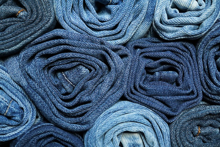
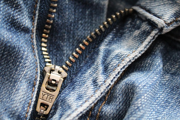
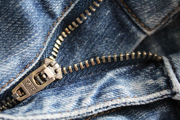
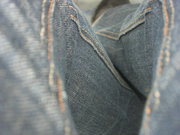
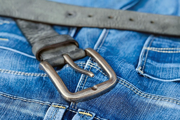
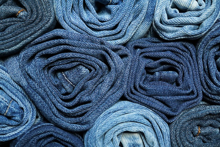
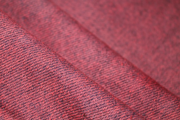
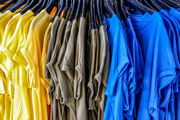
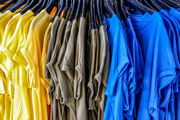
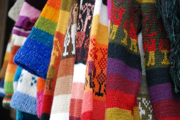
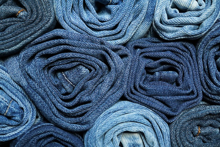
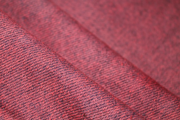
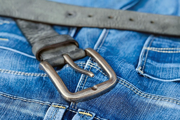
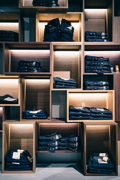
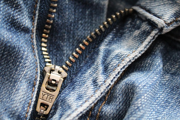


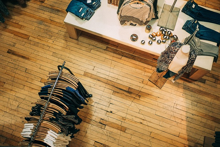
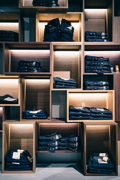
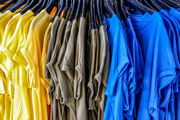
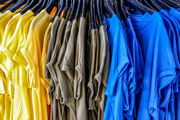
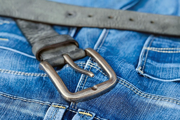
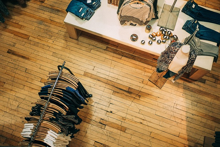
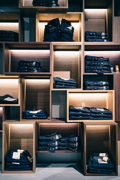
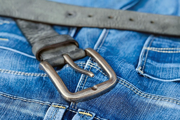
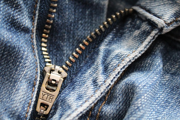
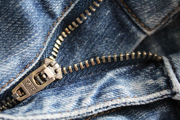
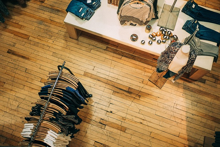
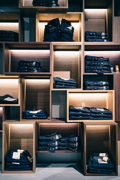
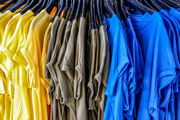
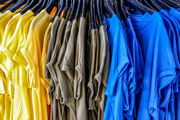
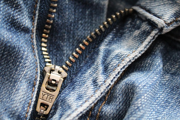
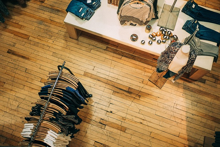
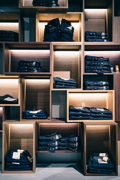
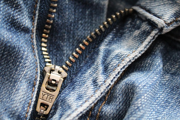
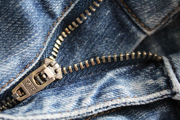
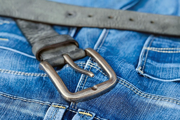

In [99]:
for entry in query_entries:
    result_columns = []
    for config in retrieval_configs:
        matching_row = next(
            row
            for row in result_rows
            if row["query"]["image_id"] == entry["image_id"]
            and row["config"]["title"] == config["title"]
        )

        query_cards = [
            build_result_card_html(
                entry["image_path"],
                title=f'Query: {entry["image_id"]}',
                subtitle=f'label: {shorten_text(entry["label"])}',
                body=f'query label: {shorten_text(entry["label"], max_chars=48)}',
                max_size=220,
            )
        ]

        for image_id, image_filename, label, caption, similarity in matching_row["results"]:
            image_path = DATASET_ROOT / "images" / image_filename
            query_cards.append(
                build_result_card_html(
                    image_path,
                    title=image_id,
                    subtitle=f"label: {shorten_text(label)} | sim={similarity:.4f}",
                    body=f"label: {shorten_text(label, max_chars=48)}",
                )
            )

        result_columns.append({"title": config["title"], "cards": query_cards})

    display(HTML(f"<h2 style='margin-top: 28px;'>Query: {entry['image_id']}</h2>"))
    display_result_matrix(result_columns)

    display(HTML("<hr style='margin: 24px 0; border: none; border-top: 1px solid #ddd;' />"))

In [100]:
con.close()